In [1]:
# Imports
import jax
from jax import numpy as jnp
from jax import random

from flax import nnx
import optax

from matplotlib import pyplot as plt

from helper import DataLoader, get_sinusoid_example
seed = 239238

In [2]:
# Overview over active learning goal and procedure

In [3]:
# Data creation: Function that samples a y value given x
# and creates some small train set

def sample_labels(x, sample_variance, key):
    # Calculates labels for points x and 
    # adds unbiased Gaussian noise with sample_variance
    
    x = jnp.atleast_2d(x) # (number_points, point_dimension)
    x = x.squeeze(-1) # Assume one-dimensional x values
    y_true = jnp.sinc(x)
    noise = random.normal(key, y_true.shape) * jnp.sqrt(sample_variance)
    return y_true + noise

key = random.key(seed)
x = jnp.linspace(0.2,5,100)[:,None]

y = sample_labels(x, 0.0005, key)[:,None]

X_train, y_train, X_valid, y_valid, X_test, y_test = get_sinusoid_example(
    num_train_data=100,
    num_valid_data=20,
    num_test_data=20,
    sigma_noise=0.003,
    intervals=[(0, 2), (4, 5), (6, 8)],
    rng_key=jax.random.key(0),
)

dataloader = DataLoader(x, y, batch_size=10)

In [4]:
# Model definition

class Model(nnx.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, rngs):
        self.linear1 = nnx.Linear(in_channels, hidden_channels, rngs=rngs)
        self.linear2 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear3 = nnx.Linear(hidden_channels, out_channels, rngs=rngs)
    def __call__(self, x):
        x = nnx.tanh(self.linear1(x))
        x = nnx.tanh(self.linear2(x))
        return self.linear3(x)

model = Model(
    in_channels=1,
    hidden_channels=128,
    out_channels=1,
    rngs=nnx.Rngs(seed))

@nnx.jit
def train_step(model, optimizer, x, y):
    
    def loss_fn(model):
        y_pred = model(x)  # Call methods directly
        return jnp.sum((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)  # Inplace updates

    return loss, grads

In [5]:
# Model training loop

def train_model(model, data, n_epochs, lr):
    # Create optimizer
    optimizer = nnx.Optimizer(model, optax.adam(lr))  # Reference sharing

    # Train epoch
    for epoch in range(n_epochs):
        for x_batch, y_batch in dataloader:
            loss, grad = train_step(model, optimizer, x_batch, y_batch)

        if epoch % 100 == 0:
            print(f"[epoch {epoch}]: loss: {loss:.4f}")
            #print(f"                 grad: {grad}")
    print(f"Final loss: {loss:.4f}")
    return model

# Train model

model = train_model(model, dataloader, n_epochs=1000, lr=1e-3)

[epoch 0]: loss: 0.2142
[epoch 100]: loss: 0.0565
[epoch 200]: loss: 0.0588
[epoch 300]: loss: 0.0605
[epoch 400]: loss: 0.0278
[epoch 500]: loss: 0.0337
[epoch 600]: loss: 0.0284
[epoch 700]: loss: 0.0120
[epoch 800]: loss: 0.0089
[epoch 900]: loss: 0.0171
Final loss: 0.0086


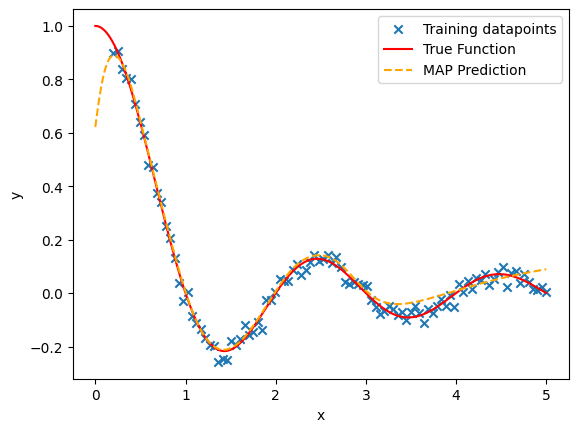

In [6]:
# Trained model visualization

plt.scatter(x, y, marker="x", label="Training datapoints")

x_true = jnp.linspace(0,5,10000)[:,None]
y_true = sample_labels(x_true, 0, key)
plt.plot(x_true, y_true, color="red", label="True Function")

y_pred = jax.vmap(model)(x_true)
plt.plot(x_true, y_pred, color="orange", linestyle="--", label="MAP Prediction")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [7]:
# Uncertainty quantification using laplax



In [8]:
# Visualization with uncertainty, optimal next data point